# Nuclearity Prediction from simple PDF-based descriptiors

This notebook aims at predicting the number of heavy atoms in the structure using several descriptors of a calculated pair distribution function G(r).

**Dataset**: Calculated PDFs of CeO2-derived clusters

**Classes**: Nuclearity classes from calculated PDF data

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

# Add parent directory to path for config import
sys.path.insert(0, '../../')
from config import get_path, setup_workdir

## Dataset Overview

Let's look at the distribution of CeO2 cluster nuclearities in our dataset.

Working directory: /workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs


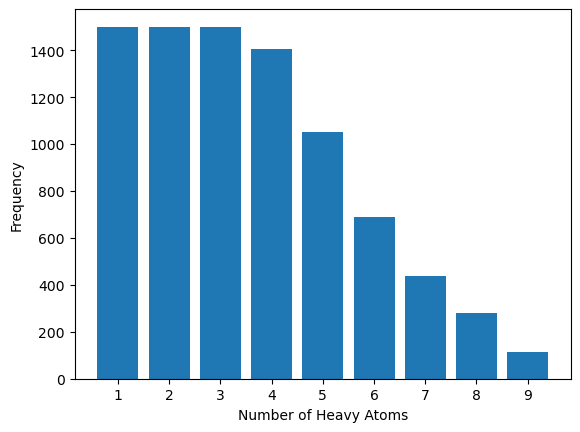

In [2]:
# Set working directory and paths using config
setup_workdir('ceo2_calculated_pdfs')
labels_path = get_path('labels') / 'ceo2_labels.txt'

def read_txt_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    return [int(line.strip()) for line in lines]

def count_occurrences(numbers):
    count_dict = {str(i): 0 for i in range(1, 10)}
    for number in numbers:
        count_dict[str(number)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    numbers = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.bar(numbers, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.show()

numbers = read_txt_file(labels_path)
count_dict = count_occurrences(numbers)
plot_bar_chart(count_dict)

## Feature Extraction from PDF Files

We'll extract comprehensive features directly from G(r) including:
- Peak areas and ratios
- Peak positions and heights
- Coordination shell integrals
- PDF moments descriptors

PDF files directory: /workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs
Feature output directory: /workspace/home/pdf-nn-data/ceo2_clusters/pdf_features
Found 10001 PDF files to process
/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/3_9431.dat


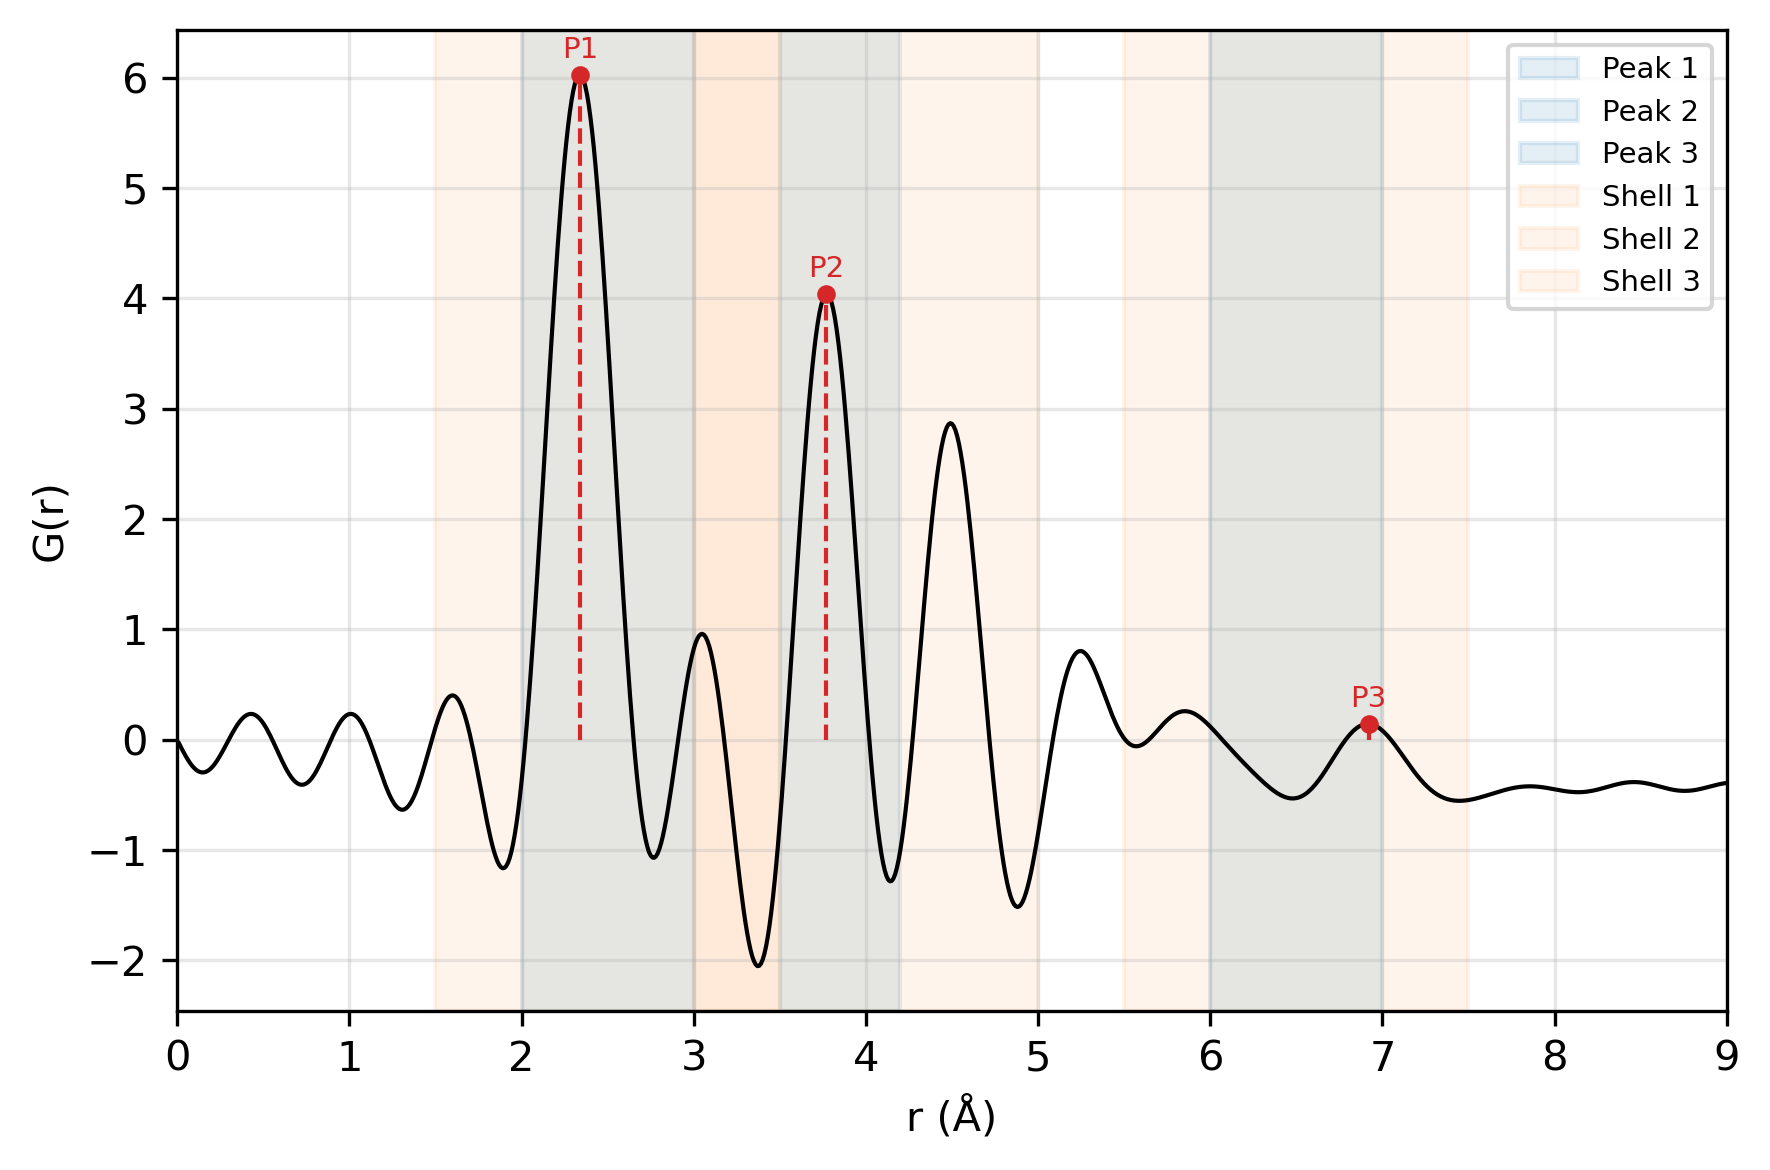

In [3]:
# Setup directories
pdf_dir = get_path('ceo2_calculated_pdfs')
pdf_features_dir = get_path('ceo2_clusters') / 'pdf_features'
pdf_features_dir.mkdir(parents=True, exist_ok=True)

print(f"PDF files directory: {pdf_dir}")
print(f"Feature output directory: {pdf_features_dir}")

files_pdf = list(pdf_dir.glob('*.dat'))
print(f"Found {len(files_pdf)} PDF files to process")

# Plot example PDF with extracted feature regions/markers
if len(files_pdf) > 0:
    example_file = files_pdf[0]
    print(example_file)
    data = pd.read_csv(example_file, skiprows=1, delim_whitespace=True, index_col=False)
    data.columns = ['r', 'g']

    # Feature regions (same as next cell)
    peak_regions = [(2.0, 3.0, 'Peak 1'), (3.5, 4.2, 'Peak 2'), (6.0, 7.0, 'Peak 3')]
    shell_regions = [(1.5, 3.5, 'Shell 1'), (3.0, 5.0, 'Shell 2'), (5.5, 7.5, 'Shell 3')]

    # Compute peak positions/heights for annotation
    peak_positions = []
    peak_heights = []
    for r_min, r_max, _ in peak_regions:
        peak = data[(data['r'] >= r_min) & (data['r'] <= r_max)]
        if len(peak) > 0 and peak['g'].max() > 0:
            idx = peak['g'].idxmax()
            peak_positions.append(float(peak.loc[idx, 'r']))
            peak_heights.append(float(peak.loc[idx, 'g']))
        else:
            peak_positions.append((r_min + r_max) / 2.0)
            peak_heights.append(0.0)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    ax.plot(data.r, data.g, color='black', linewidth=1)

    # Shade peak regions
    for (r_min, r_max, label) in peak_regions:
        ax.axvspan(r_min, r_max, color='tab:blue', alpha=0.12, label=label)

    # Shade shell regions (lighter)
    for (r_min, r_max, label) in shell_regions:
        ax.axvspan(r_min, r_max, color='tab:orange', alpha=0.08, label=label)

    # Mark peak positions and heights
    for i, (pos, height) in enumerate(zip(peak_positions, peak_heights), start=1):
        ax.vlines(pos, 0, height, color='tab:red', linestyle='--', linewidth=1)
        ax.scatter([pos], [height], color='tab:red', s=12, zorder=5)
        ax.text(pos, height+0.1, f"P{i}", color='tab:red', fontsize=7, ha='center', va='bottom')

    ax.set_xlim(0, 9)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('G(r)')
    ax.grid(True, alpha=0.3)

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=7, loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()

In [4]:
# Enhanced feature extraction from PDF files
features_path = pdf_features_dir / 'pdf_features.txt'

print(f"Extracting features from {len(files_pdf)} PDF files...")

def extract_pdf_features(df):
    """Extract comprehensive PDF features for classification"""
    features = {}
    
    # Define peak regions (same as RDF analysis for comparison)
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (integrals of G(r))
    area1 = trapz(peak1.g, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.g, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.g, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.g.idxmax(), 'r'] if len(peak1) > 0 and peak1.g.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.g.idxmax(), 'r'] if len(peak2) > 0 and peak2.g.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.g.idxmax(), 'r'] if len(peak3) > 0 and peak3.g.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.g.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.g.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.g.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1_coord'] = trapz(df.loc[shell1_mask, 'g'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2_coord'] = trapz(df.loc[shell2_mask, 'g'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3_coord'] = trapz(df.loc[shell3_mask, 'g'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # PDF moments and shape descriptors
    r_vals = df['r'].values
    g_vals = df['g'].values
    
    # For PDF, we need to handle negative values and zero crossings
    # Use absolute values weighted by sign for moments
    g_pos = np.maximum(g_vals, 0)  # Positive part only for moment calculation
    
    # First moment (weighted average r-position of positive peaks)
    if np.sum(g_pos) > 0:
        features['moment1'] = np.sum(r_vals * g_pos) / np.sum(g_pos)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * g_pos) / np.sum(g_pos)  # Variance
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total PDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'g'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

# Extract features from all PDF files
all_features = []
with open(features_path, 'w') as f:
    # Write header
    feature_names = ['nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
                     'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
                     'height_21', 'height_31', 'shell1_coord', 'shell2_coord', 'shell3_coord', 
                     'moment1', 'moment2', 'total_integral']
    f.write(' '.join(feature_names) + '\n')
    
    for i, file_path in enumerate(files_pdf):  # Process ALL PDF files
        try:
            # Load PDF data
            data = pd.read_csv(file_path, skiprows=1, delim_whitespace=True, index_col=False)
            data.columns = ['r', 'g']
            
            # Extract features
            features = extract_pdf_features(data)
            
            # Get nuclearity from filename
            nuclearity = int(file_path.name[0])
            
            # Write to file
            feature_row = [nuclearity] + [features[name] for name in feature_names[1:]]
            f.write(' '.join(map(str, feature_row)) + '\n')
            all_features.append(feature_row)
            
        except Exception as e:
            print(f"Error processing {file_path.name}: {e}")
            continue
            
        if i % 1000 == 0:
            print(f"Extracted features from {i} files...")

print(f"Feature extraction complete")
print(f"  Features saved to: {features_path}")
print(f"  Total features per sample: {len(feature_names)-1}")

Extracting features from 10001 PDF files...
Extracted features from 0 files...
Extracted features from 1000 files...
Extracted features from 2000 files...
Extracted features from 3000 files...
Extracted features from 4000 files...
Error processing ._1_3.dat: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Extracted features from 5000 files...
Extracted features from 6000 files...
Extracted features from 7000 files...
Extracted features from 8000 files...
Extracted features from 9000 files...
Extracted features from 10000 files...
Feature extraction complete
  Features saved to: /workspace/home/pdf-nn-data/ceo2_clusters/pdf_features/pdf_features.txt
  Total features per sample: 20


Loaded 10000 samples with 20 features
Nuclearity distribution:
1    1923
2    2281
3    1821
4    1404
5    1051
6     688
7     437
8     281
9     114
Name: nuclearity, dtype: int64


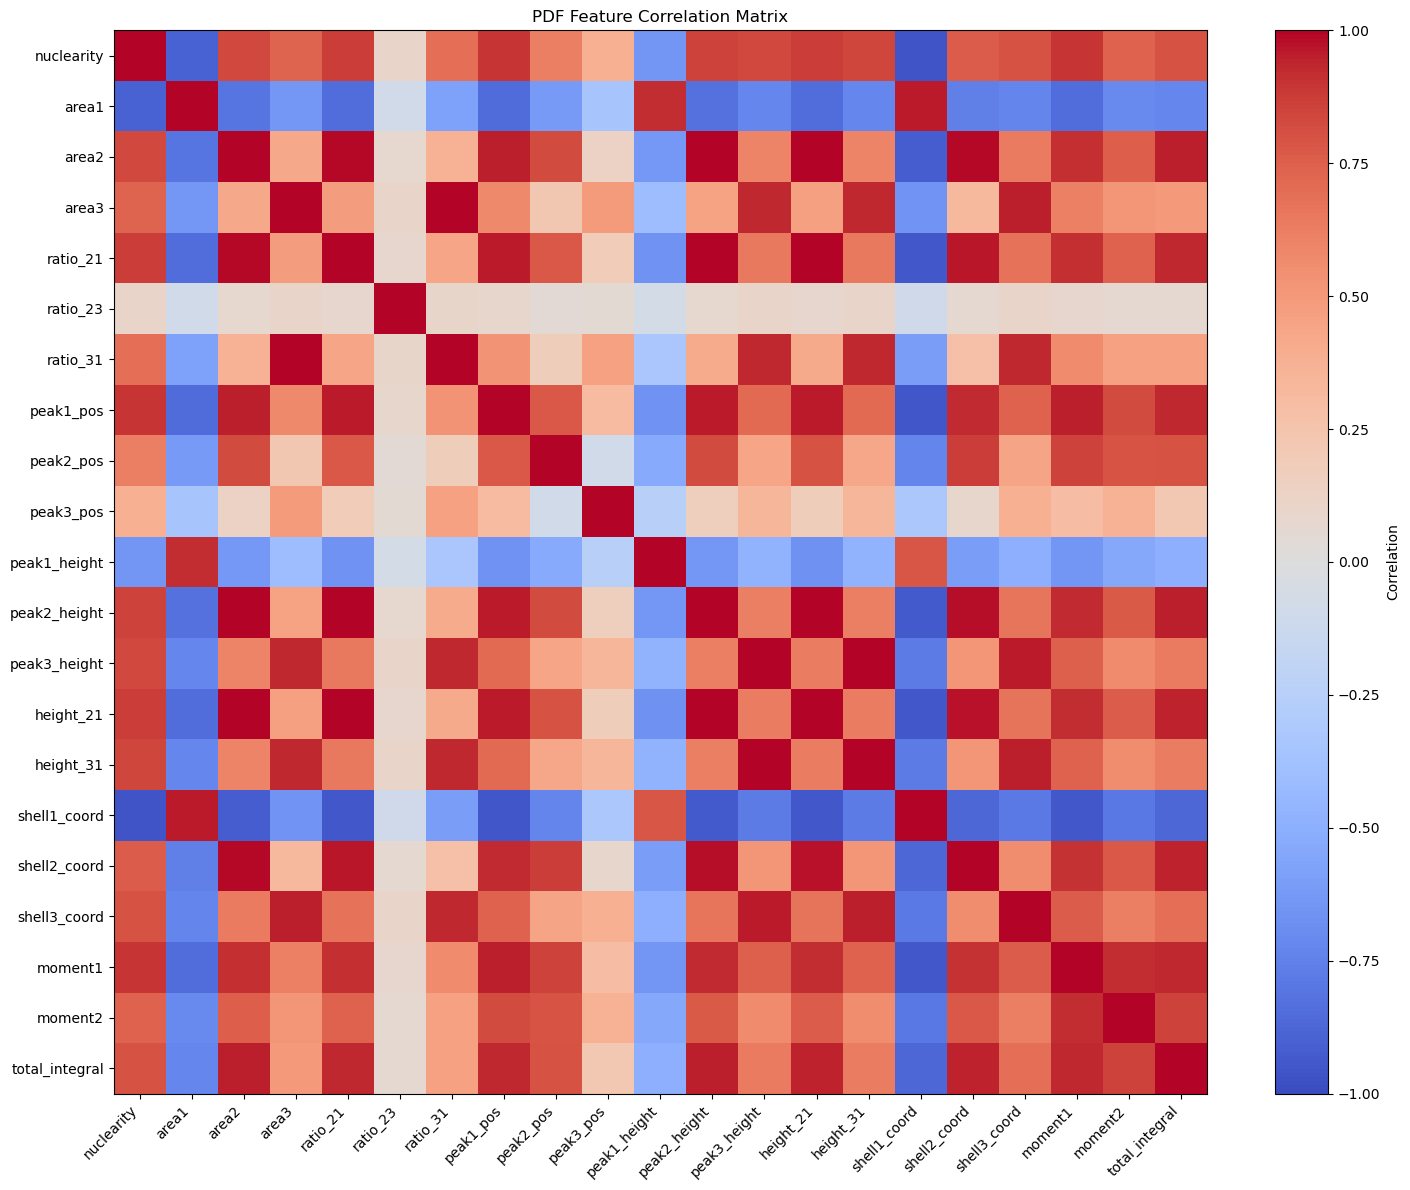

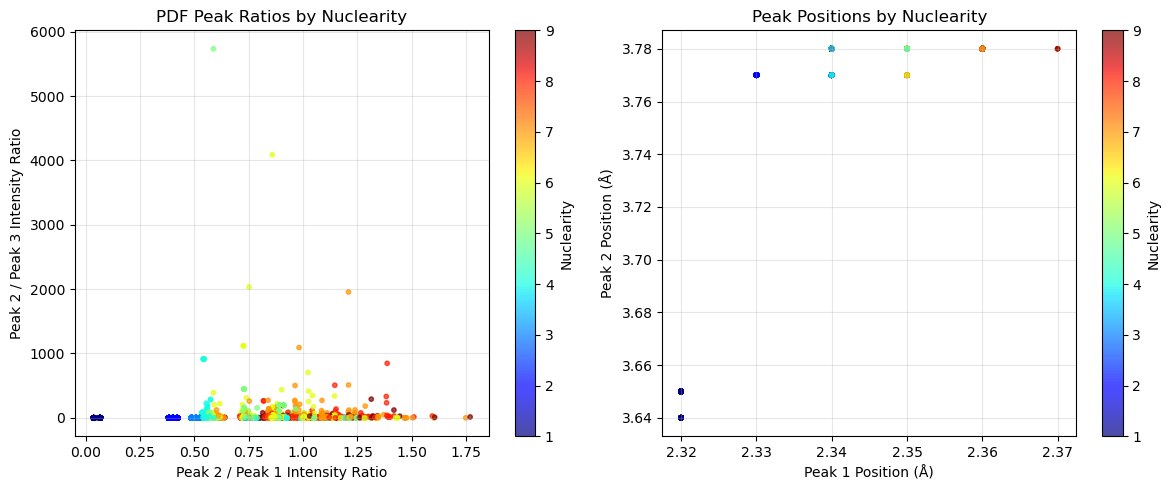

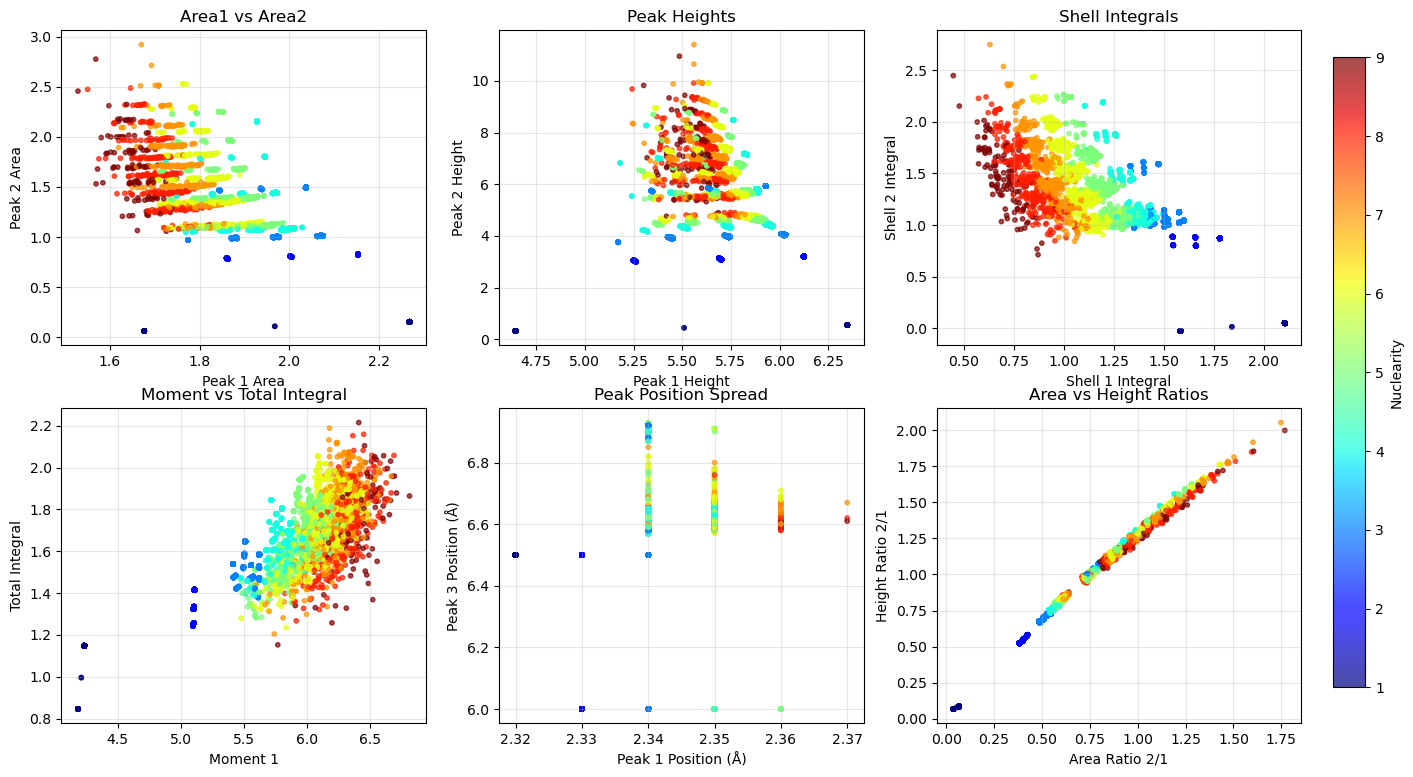


Feature statistics:
       nuclearity      area1      area2      area3   ratio_21   ratio_23  \
count   10000.000  10000.000  10000.000  10000.000  10000.000  10000.000   
mean        3.328      2.031      0.987     -0.142      0.507      7.880   
std         1.970      0.172      0.521      0.149      0.296     89.069   
min         1.000      1.530      0.062     -0.398      0.037      0.000   
25%         2.000      1.897      0.823     -0.266      0.382      0.000   
50%         3.000      2.063      1.008     -0.207      0.489      0.000   
75%         5.000      2.153      1.391     -0.069      0.732      0.000   
max         9.000      2.267      2.919      0.644      1.768   5733.739   

        ratio_31  peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  \
count  10000.000  10000.000  10000.000  10000.000  ...     10000.000   
mean      -0.066      2.336      3.750      6.438  ...         3.968   
std        0.076      0.011      0.049      0.290  ...         2.142   
min   

In [5]:
# Load and visualize PDF features
features_path = pdf_features_dir / 'pdf_features.txt'
features_data = pd.read_csv(features_path, delim_whitespace=True, header=0, index_col=False)

print(f"Loaded {len(features_data)} samples with {len(feature_names)-1} features")
print(f"Nuclearity distribution:")
print(features_data['nuclearity'].value_counts().sort_index())

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('PDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Create enhanced scatter plot with original ratios
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_data['ratio_21'], features_data['ratio_23'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 2 / Peak 1 Intensity Ratio')
plt.ylabel('Peak 2 / Peak 3 Intensity Ratio')
plt.title('PDF Peak Ratios by Nuclearity')
plt.colorbar(scatter1, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_data['peak1_pos'], features_data['peak2_pos'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 1 Position (Å)')
plt.ylabel('Peak 2 Position (Å)')
plt.title('Peak Positions by Nuclearity')
plt.colorbar(scatter2, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional scatter plots for clustering insight
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
scatter_kwargs = dict(c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)

axes[0, 0].scatter(features_data['area1'], features_data['area2'], **scatter_kwargs)
axes[0, 0].set_xlabel('Peak 1 Area')
axes[0, 0].set_ylabel('Peak 2 Area')
axes[0, 0].set_title('Area1 vs Area2')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(features_data['peak1_height'], features_data['peak2_height'], **scatter_kwargs)
axes[0, 1].set_xlabel('Peak 1 Height')
axes[0, 1].set_ylabel('Peak 2 Height')
axes[0, 1].set_title('Peak Heights')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(features_data['shell1_coord'], features_data['shell2_coord'], **scatter_kwargs)
axes[0, 2].set_xlabel('Shell 1 Integral')
axes[0, 2].set_ylabel('Shell 2 Integral')
axes[0, 2].set_title('Shell Integrals')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(features_data['moment1'], features_data['total_integral'], **scatter_kwargs)
axes[1, 0].set_xlabel('Moment 1')
axes[1, 0].set_ylabel('Total Integral')
axes[1, 0].set_title('Moment vs Total Integral')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(features_data['peak1_pos'], features_data['peak3_pos'], **scatter_kwargs)
axes[1, 1].set_xlabel('Peak 1 Position (Å)')
axes[1, 1].set_ylabel('Peak 3 Position (Å)')
axes[1, 1].set_title('Peak Position Spread')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].scatter(features_data['ratio_21'], features_data['height_21'], **scatter_kwargs)
axes[1, 2].set_xlabel('Area Ratio 2/1')
axes[1, 2].set_ylabel('Height Ratio 2/1')
axes[1, 2].set_title('Area vs Height Ratios')
axes[1, 2].grid(True, alpha=0.3)

fig.colorbar(axes[0, 0].collections[0], ax=axes, label='Nuclearity', shrink=1, cax=fig.add_axes([0.92, 0.15, 0.02, 0.7]))
#fig.suptitle('CeO2-based clusters PDF Feature Scatter Plots Colored by Nuclearity')
#plt.tight_layout()
plt.show()

# Display feature statistics
print("\nFeature statistics:")
print(features_data.describe().round(3))

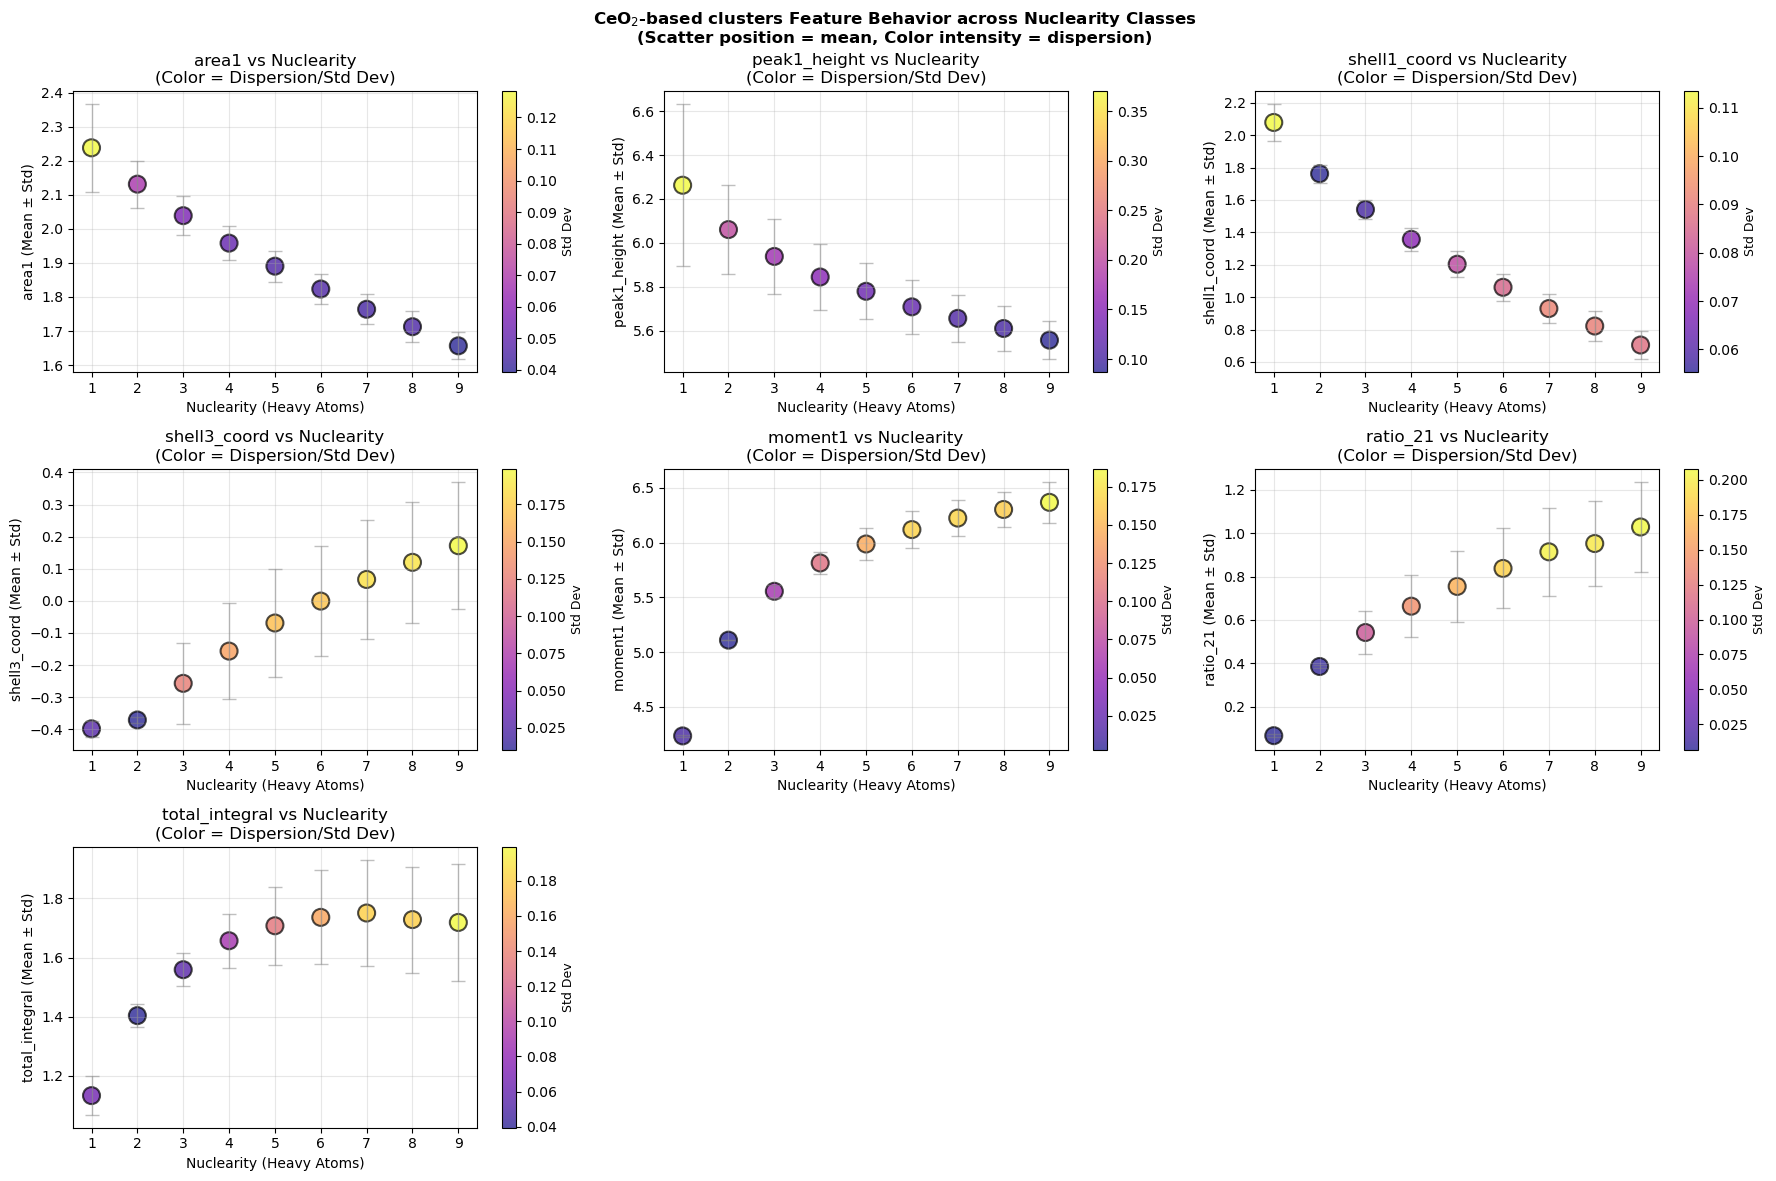

In [6]:

# Feature vs Nuclearity with Dispersion Analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes_flat = axes.flatten()

# Calculate mean and std for each feature grouped by nuclearity
feature_dispersion = {}
nuclearity_values = sorted(features_data['nuclearity'].unique())

# Select key features for visualization
key_features = ['area1', 'peak1_height', 'shell1_coord', 'shell3_coord', 'moment1', 'ratio_21', 'total_integral']

for idx, feature in enumerate(key_features):
    ax = axes_flat[idx]
    
    # Calculate mean and std for each nuclearity
    feature_means = []
    feature_stds = []
    
    for nuc in nuclearity_values:
        nuc_data = features_data[features_data['nuclearity'] == nuc][feature]
        feature_means.append(nuc_data.mean())
        feature_stds.append(nuc_data.std())
    
    # Create scatter plot: nuclearity vs feature value, colored by dispersion (std)
    scatter = ax.scatter(nuclearity_values, feature_means, 
                        c=feature_stds, cmap='plasma', s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    
    # Add error bars showing std deviation
    ax.errorbar(nuclearity_values, feature_means, yerr=feature_stds, fmt='none', 
               ecolor='gray', alpha=0.5, capsize=5, linewidth=1)
    
    ax.set_xlabel('Nuclearity (Heavy Atoms)')
    ax.set_ylabel(f'{feature} (Mean ± Std)')
    ax.set_title(f'{feature} vs Nuclearity\n(Color = Dispersion/Std Dev)')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(nuclearity_values)
    
    # Add colorbar for this subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Std Dev', fontsize=9)

# Hide any unused subplots
for j in range(len(key_features), len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle('CeO$_{2}$-based clusters Feature Behavior across Nuclearity Classes\n(Scatter position = mean, Color intensity = dispersion)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Model Training: Gradient Boosting Classifier

Feature matrix shape: (10000, 20)
Target distribution: [   0 1923 2281 1821 1404 1051  688  437  281  114]
Training Gradient Boosting Classifier on PDF features...

Gradient Boosting Classification Results (PDF features):
Accuracy: 0.997
F1-score (weighted): 0.996
F1-score (macro): 0.983

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       385
           2       1.00      1.00      1.00       456
           3       1.00      1.00      1.00       364
           4       1.00      1.00      1.00       281
           5       1.00      1.00      1.00       210
           6       0.98      1.00      0.99       138
           7       1.00      0.97      0.98        87
           8       0.95      0.98      0.96        56
           9       0.95      0.87      0.91        23

    accuracy                           1.00      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       1.00     

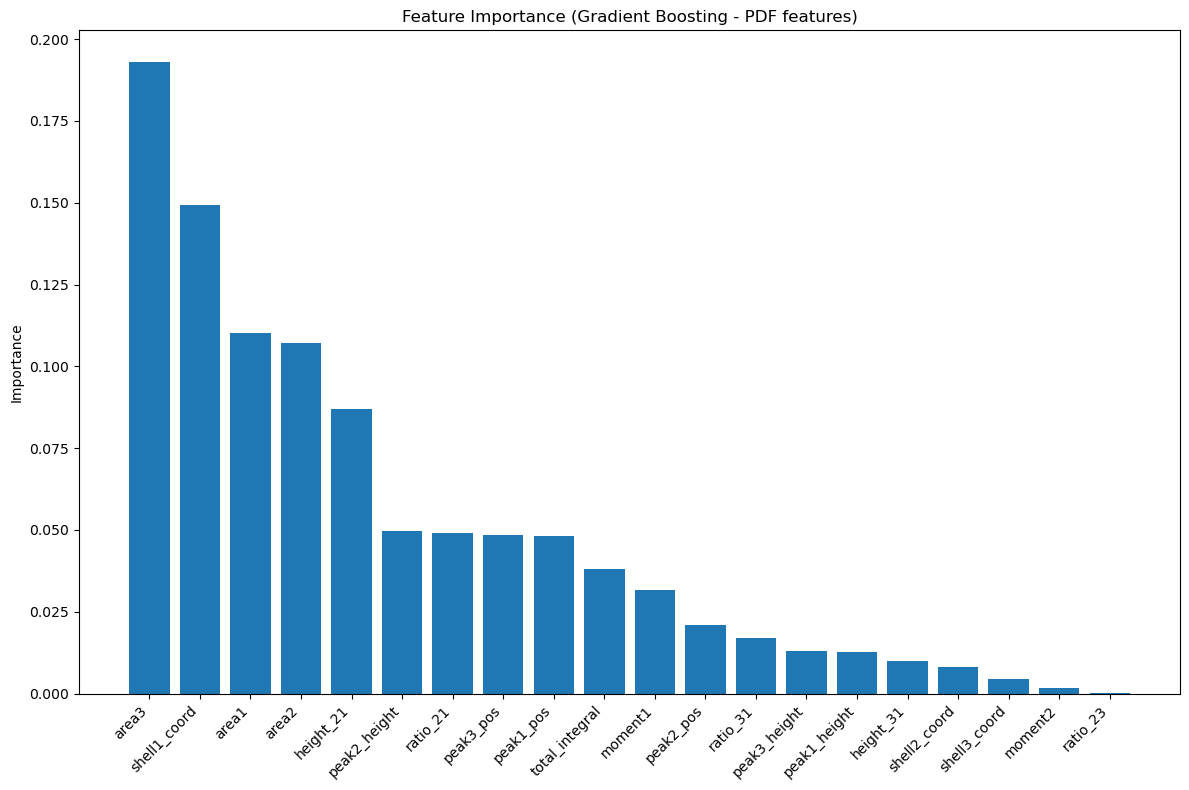


Top 5 most important PDF features:
1. area3: 0.193
2. shell1_coord: 0.149
3. area1: 0.110
4. area2: 0.107
5. height_21: 0.087


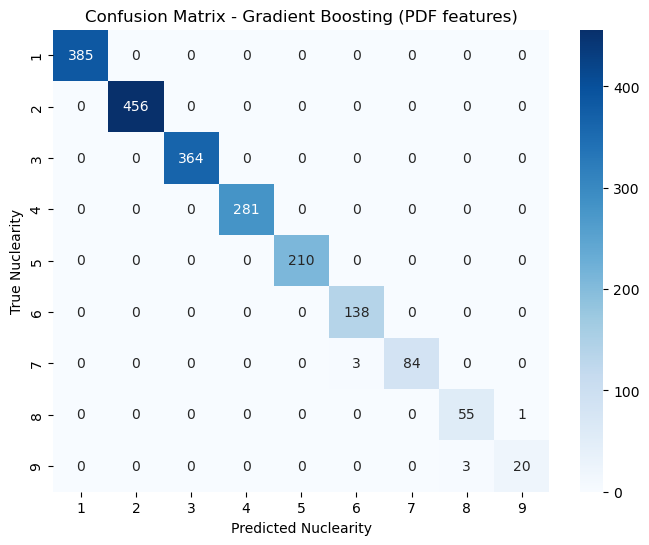

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=6,
    random_state=42
)

print("Training Gradient Boosting Classifier on PDF features...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nGradient Boosting Classification Results (PDF features):")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features:")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance[idx]:.3f}")

# Confusion matrix
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
plt.xlabel('Predicted Nuclearity')
plt.ylabel('True Nuclearity')
plt.title('Confusion Matrix - Gradient Boosting (PDF features)')
plt.show()

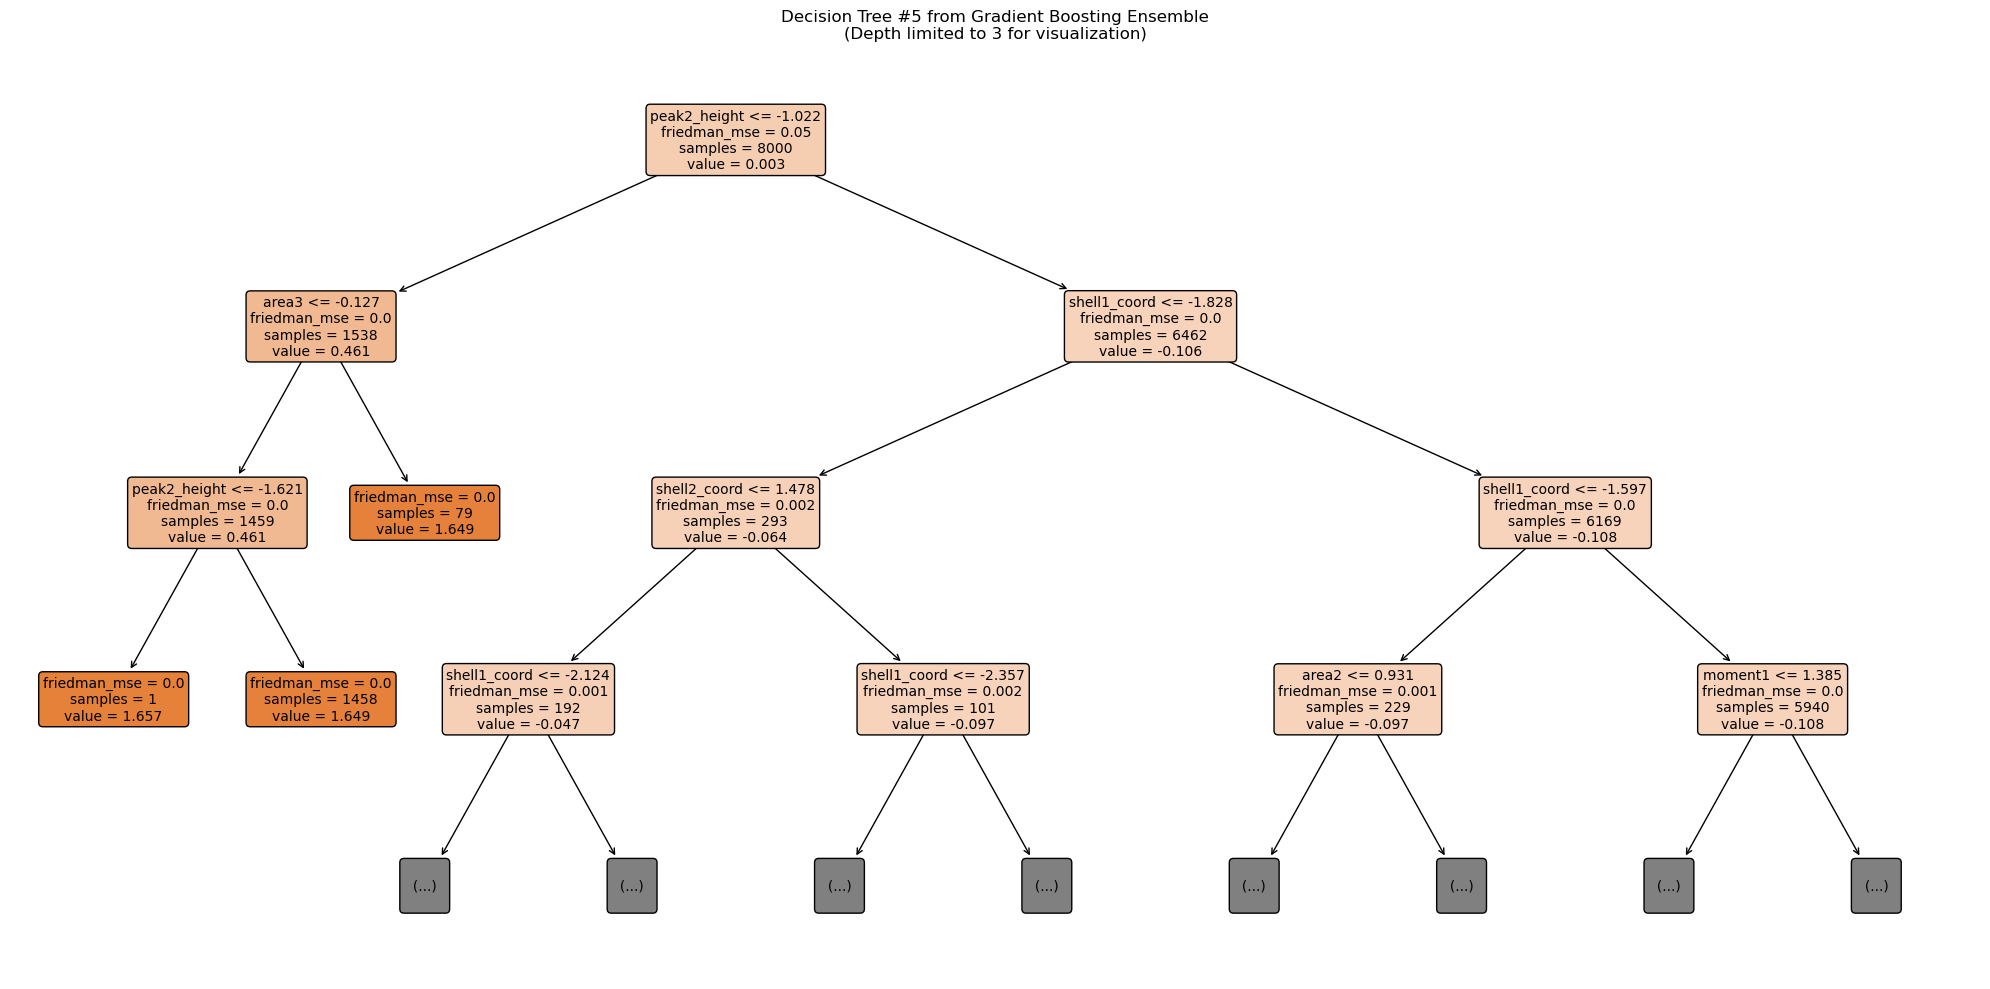

Tree #5 details:
  Number of nodes: 67
  Maximum depth: 6
  Number of leaves: 34


In [9]:
# Visualize a single tree from the Gradient Boosting ensemble
from sklearn.tree import plot_tree

# Select a tree to visualize (e.g., the 5th estimator)
tree_index = 4  # 5th tree (0-indexed)

plt.figure(figsize=(20, 10))
plot_tree(
    gb_classifier.estimators_[tree_index, 0],
    feature_names=feature_names_clean,
    class_names=[str(i) for i in sorted(np.unique(y))],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Limit depth for visualization clarity
)
plt.title(f'Decision Tree #{tree_index + 1} from Gradient Boosting Ensemble\n(Depth limited to 3 for visualization)')
plt.tight_layout()
plt.show()

print(f"Tree #{tree_index + 1} details:")
print(f"  Number of nodes: {gb_classifier.estimators_[tree_index, 0].tree_.node_count}")
print(f"  Maximum depth: {gb_classifier.estimators_[tree_index, 0].tree_.max_depth}")
print(f"  Number of leaves: {gb_classifier.estimators_[tree_index, 0].tree_.n_leaves}")

## Model Training: Random Forest Classifier

Training Random Forest Classifier with hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits


Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.990

Random Forest Classification Results (PDF features):
Accuracy: 0.993
F1-score (weighted): 0.993
F1-score (macro): 0.974

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       385
           2       1.00      1.00      1.00       456
           3       1.00      1.00      1.00       364
           4       1.00      1.00      1.00       281
           5       1.00      0.99      1.00       210
           6       0.95      1.00      0.98       138
           7       0.95      0.95      0.95        87
           8       0.96      0.91      0.94        56
           9       0.95      0.87      0.91        23

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.99      0.99      0.99     

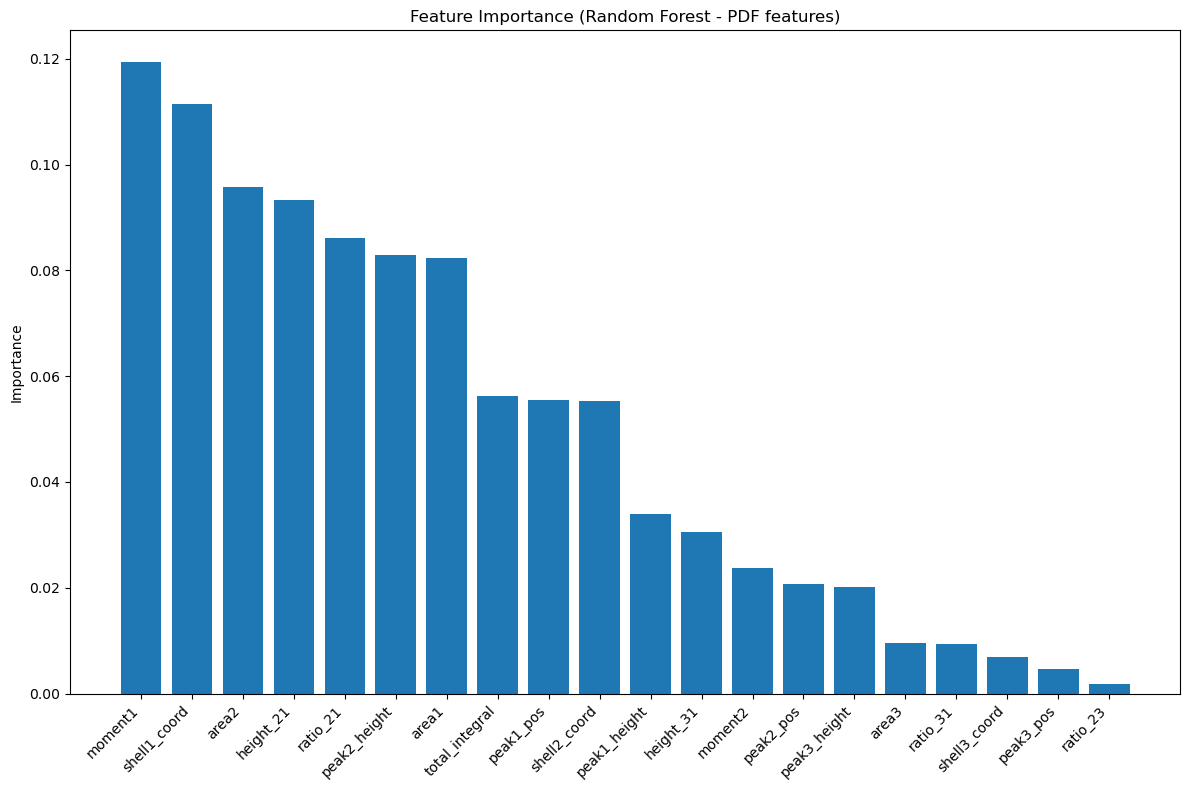


Top 5 most important PDF features (Random Forest):
1. moment1: 0.119
2. shell1_coord: 0.112
3. area2: 0.096
4. height_21: 0.093
5. ratio_21: 0.086


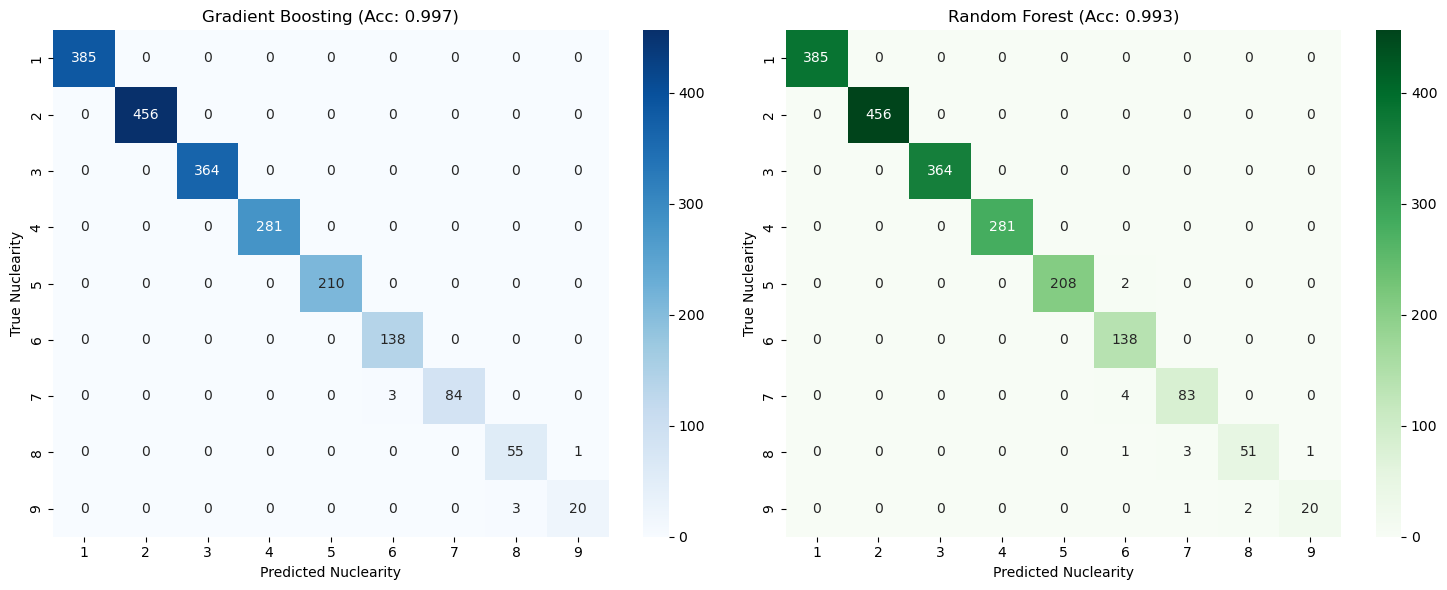


Per-class accuracy comparison:
Class      GB Precision    RF Precision    GB Recall    RF Recall   
----------------------------------------------------------------------
1          1.000           1.000           1.000        1.000       
2          1.000           1.000           1.000        1.000       
3          1.000           1.000           1.000        1.000       
4          1.000           1.000           1.000        1.000       
5          1.000           1.000           1.000        0.990       
6          0.979           0.952           1.000        1.000       
7          1.000           0.954           0.966        0.954       
8          0.948           0.962           0.982        0.911       
9          0.952           0.952           0.870        0.870       


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Random Forest Classifier with hyperparameter tuning
print("Training Random Forest Classifier with hyperparameter tuning...")

# Define parameter grid for optimization
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Create Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Make predictions with best model
y_pred_rf = best_rf.predict(X_test_scaled)

# Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nRandom Forest Classification Results (PDF features):")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance analysis
feature_importance_rf = best_rf.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest - PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important PDF features (Random Forest):")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance_rf[idx]:.3f}")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gradient Boosting confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[0].set_xlabel('Predicted Nuclearity')
axes[0].set_ylabel('True Nuclearity')
axes[0].set_title(f'Gradient Boosting (Acc: {accuracy:.3f})')

# Random Forest confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1].set_xlabel('Predicted Nuclearity')
axes[1].set_ylabel('True Nuclearity')
axes[1].set_title(f'Random Forest (Acc: {accuracy_rf:.3f})')

plt.tight_layout()
plt.show()

# Calculate per-class accuracy
from sklearn.metrics import precision_score, recall_score

unique_classes = sorted(np.unique(y))
print(f"\nPer-class accuracy comparison:")
print(f"{'Class':<10} {'GB Precision':<15} {'RF Precision':<15} {'GB Recall':<12} {'RF Recall':<12}")
print("-" * 70)

for cls in unique_classes:
    gb_prec = precision_score(y_test == cls, y_pred == cls)
    rf_prec = precision_score(y_test == cls, y_pred_rf == cls)
    gb_rec = recall_score(y_test == cls, y_pred == cls)
    rf_rec = recall_score(y_test == cls, y_pred_rf == cls)
    print(f"{cls:<10} {gb_prec:<15.3f} {rf_prec:<15.3f} {gb_rec:<12.3f} {rf_rec:<12.3f}")

## Model Training: Improved Bayesian Approaches

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures

print("BAYESIAN APPROACHES WITH PDF FEATURES")
print("="*50)

# ============================================================================
# Strategy 1: Feature Selection for Naive Bayes
# ============================================================================
print("1. Feature Selection for Naive Bayes")

# Use mutual information to select most informative features
selector = SelectKBest(score_func=mutual_info_classif, k=10)  # Select top 10 features
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected features: {list(selected_features)}")

# Train Naive Bayes on selected features
nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted')

print(f"Improved Naive Bayes: {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# ============================================================================
# Strategy 2: Tuned Logistic Regression  
# ============================================================================
print("\n2. Hyperparameter Tuning for Logistic Regression")

# Grid search for optimal regularization
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='ovr'),
    param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted')

print(f"Improved Logistic Regression: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# ============================================================================
# Strategy 3: Polynomial Features
# ============================================================================
print("\n3. Feature Engineering - Polynomial Features")

# Create polynomial features for top 5 most important features
feature_importance_rf = best_rf.feature_importances_
top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} features from top 5")

# Train LogReg on polynomial features
lr_poly = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted')

print(f"LogReg + Polynomial Features: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

# ============================================================================
# Strategy 4: Ensemble
# ============================================================================
print("\n4. Ensemble of Bayesian Methods")

bayesian_ensemble = VotingClassifier([
    ('lr_tuned', lr_grid.best_estimator_),
    ('nb', GaussianNB())
], voting='soft')

bayesian_ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = bayesian_ensemble.predict(X_test_scaled)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print(f"Bayesian Ensemble: {accuracy_ensemble:.3f} accuracy, {f1_ensemble:.3f} F1")

BAYESIAN APPROACHES WITH PDF FEATURES
1. Feature Selection for Naive Bayes
Selected features: ['area1', 'area2', 'ratio_21', 'peak1_height', 'peak2_height', 'peak3_height', 'height_21', 'height_31', 'shell1_coord', 'moment1']
Improved Naive Bayes: 0.838 accuracy, 0.837 F1

2. Hyperparameter Tuning for Logistic Regression


/workspace/miniconda3/envs/pdfnn/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Best LogReg params: {'C': 100, 'max_iter': 1000, 'solver': 'lbfgs'}
Improved Logistic Regression: 0.902 accuracy, 0.899 F1

3. Feature Engineering - Polynomial Features
Polynomial features: 15 features from top 5
LogReg + Polynomial Features: 0.947 accuracy, 0.947 F1

4. Ensemble of Bayesian Methods


/workspace/miniconda3/envs/pdfnn/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Bayesian Ensemble: 0.801 accuracy, 0.794 F1


## Model Training: Simple Neural Network

2026-02-13 14:24:04.452154: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 14:24:04.610154: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 14:24:04.614591: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-13 14:24:04.614621: I tensorflow/compiler/xla

Neural network input: 20 PDF features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Building neural network for PDF-based nuclearity classification...
Model architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               2688      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)          

2026-02-13 14:24:06.835159: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: /usr/lib/x86_64-linux-gnu/libcuda.so.1: file too short
2026-02-13 14:24:06.835202: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-13 14:24:06.835226: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist
2026-02-13 14:24:06.835486: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.



Training neural network...
Epoch 1/150
100/100 [==============================] - 1s 5ms/step - loss: 1.4892 - accuracy: 0.5000 - categorical_crossentropy: 1.4892 - val_loss: 1.1635 - val_accuracy: 0.7069 - val_categorical_crossentropy: 1.1635 - lr: 0.0010
Epoch 2/150
100/100 [==============================] - 0s 2ms/step - loss: 0.8632 - accuracy: 0.7014 - categorical_crossentropy: 0.8632 - val_loss: 0.7195 - val_accuracy: 0.7950 - val_categorical_crossentropy: 0.7195 - lr: 0.0010
Epoch 3/150
100/100 [==============================] - 0s 2ms/step - loss: 0.6751 - accuracy: 0.7492 - categorical_crossentropy: 0.6751 - val_loss: 0.4676 - val_accuracy: 0.8512 - val_categorical_crossentropy: 0.4676 - lr: 0.0010
Epoch 4/150
100/100 [==============================] - 0s 2ms/step - loss: 0.5330 - accuracy: 0.7955 - categorical_crossentropy: 0.5330 - val_loss: 0.3124 - val_accuracy: 0.8706 - val_categorical_crossentropy: 0.3124 - lr: 0.0010
Epoch 5/150
100/100 [==============================]

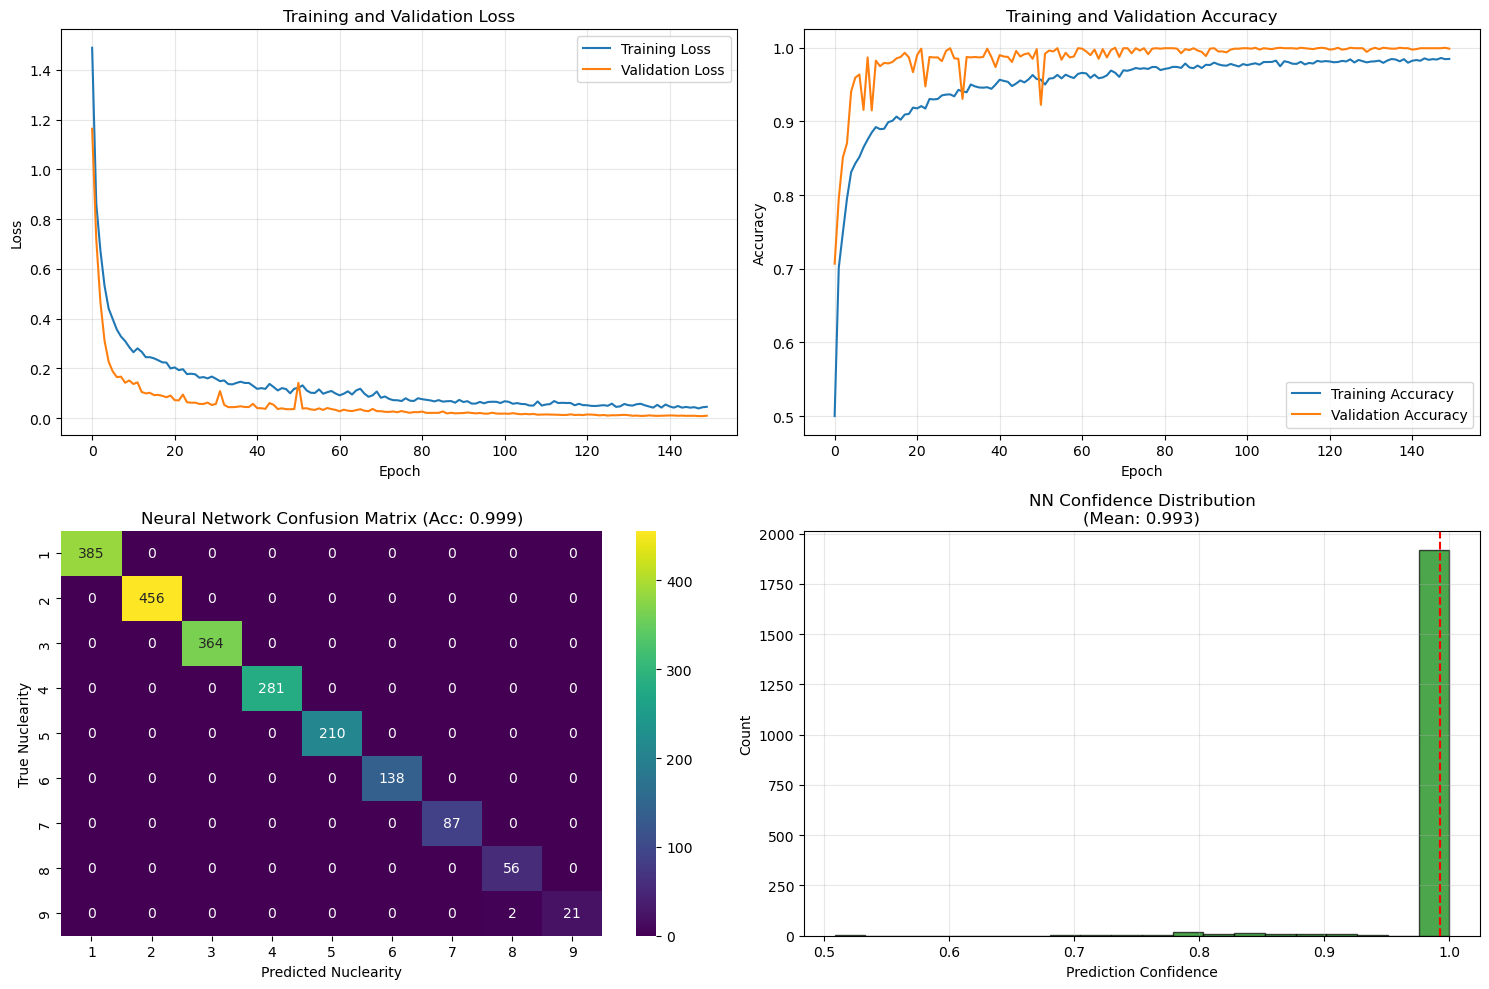

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} PDF features")
print(f"Classes: {sorted(np.unique(y))}")

# Convert to categorical for classification
num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)  # -1 because nuclearity starts at 1

# Split the data
X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build neural network
print("Building neural network for PDF-based nuclearity classification...")

model = keras.Sequential([
    # Input layer with dropout for regularization
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layers with decreasing size
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer for classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile with appropriate loss for classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'categorical_crossentropy']
)

print(f"Model architecture:")
model.summary()

# Training with early stopping and learning rate reduction
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

print("\nTraining neural network...")
num_epochs = 150
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=64,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluation and predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1  # +1 to convert back to nuclearity

# Calculate classification metrics
accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro')

print(f"\nNeural Network Classification Results (PDF features):")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Visualization: Training history and confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='viridis', ax=axes[1, 0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'Neural Network Confusion Matrix (Acc: {accuracy_nn:.3f})')

# Prediction confidence distribution
confidence_scores = np.max(y_pred_prob, axis=1)
axes[1, 1].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'NN Confidence Distribution\n(Mean: {confidence_scores.mean():.3f})')
axes[1, 1].axvline(confidence_scores.mean(), color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
Permutation explainer: 301it [00:31,  7.02it/s]                         


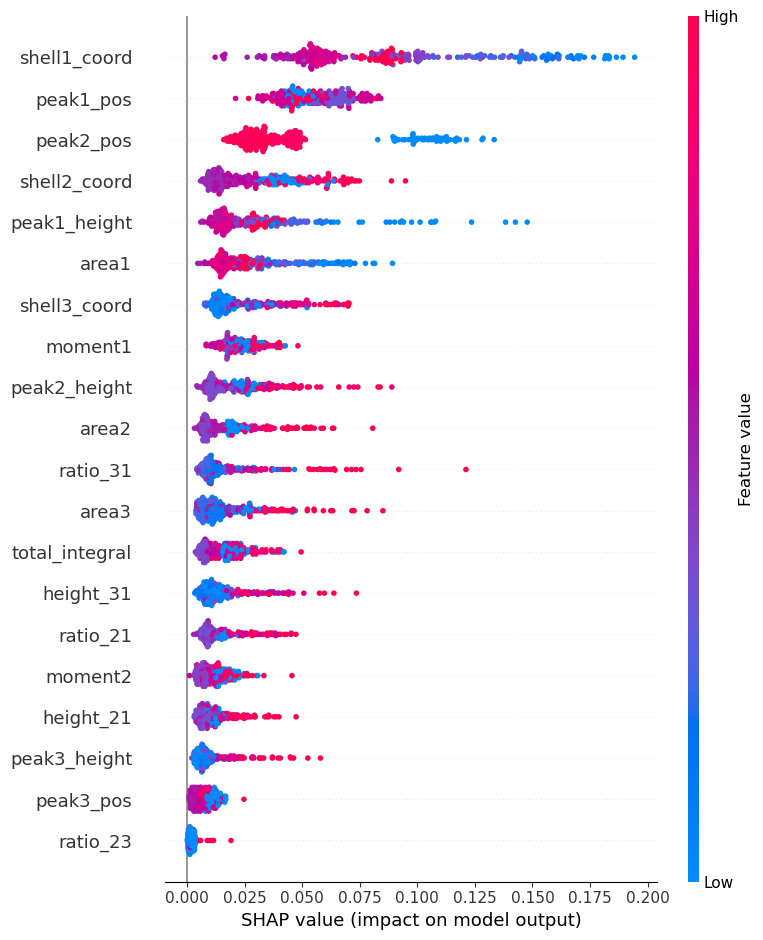

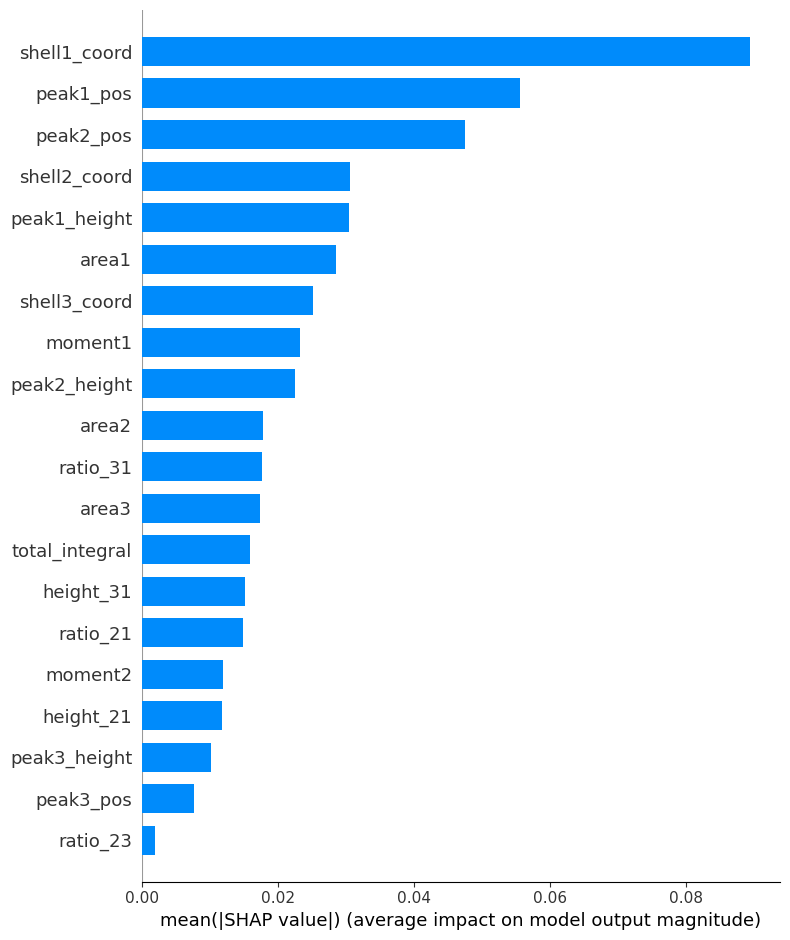

In [14]:
# SHAP explanations for the neural network (sampled for speed)
try:
    import shap
except ImportError as exc:
    raise ImportError("Install shap (pip install shap) before running this cell.") from exc

# Sample a subset for SHAP to keep runtime reasonable
rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
sample_size = min(300, X_test_scaled.shape[0])

background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
sample_idx = rng.choice(X_test_scaled.shape[0], size=sample_size, replace=False)

background = X_train_scaled[background_idx]
X_shap = X_test_scaled[sample_idx]

# Build SHAP explainer for the trained Keras model
explainer = shap.Explainer(model, background, feature_names=feature_names_clean)
shap_values = explainer(X_shap)

# For multi-class outputs, summarize by mean absolute contribution per feature
if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    shap_values_mean = shap.Explanation(
        values=np.mean(np.abs(shap_values.values), axis=2),
        base_values=np.mean(shap_values.base_values, axis=1) if shap_values.base_values.ndim == 2 else shap_values.base_values,
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )
    shap_to_plot = shap_values_mean
else:
    shap_to_plot = shap_values

# Summary plots
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, show=True)
shap.summary_plot(shap_to_plot, features=X_shap, feature_names=feature_names_clean, plot_type="bar", show=True)

## Final Performance Comparison

In [ ]:
# ============================================================================
# FINAL ALGORITHM COMPARISON - PDF FEATURES
# ============================================================================
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Bayesian Ensemble':<35} {accuracy_ensemble:.3f}        {f1_ensemble:.3f}")
print(f"{'Naive Bayes (selected)':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes (improved)', 
              'Tuned LogReg', 'LogReg+Poly', 'Bayesian Ensemble', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_ensemble, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_ensemble, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print("Analysis complete! Results saved to:", pdf_features_dir)


FINAL ALGORITHM PERFORMANCE COMPARISON (PDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      1.000        1.000
Gradient Boosting                   0.995        0.995
Random Forest                       0.994        0.994
LogReg + Polynomial                 0.953        0.952
Bayesian Ensemble                   0.799        0.791
Naive Bayes (selected)              0.832        0.832
Tuned Logistic Regression           0.903        0.901

Best Accuracy: Neural Network (1.000)
Best F1-Score: Neural Network (1.000)

Analysis complete! Results saved to: /Volumes/Extreme SSD/PDF NN/pdf-nn-data/ceo2_clusters/pdf_features
